In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from barebone_llm.attention import MultiHeadAttention
from barebone_llm.tokenizer import SimpleTokenizerV2
from barebone_llm.config import GPT_CONFIG_124M
from barebone_llm.model import DummyGPTModel


In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1))) 
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0) 
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(f"Output shape : {logits.shape}")
print(logits)

Output shape : torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [5]:
torch.manual_seed(123) 
batch_example = torch.randn(2,5)
layer = torch.nn.Sequential(torch.nn.Linear(5,6),torch.nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print(f"Mean = {mean}")
print(f"var = {var}")

Mean = tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
var = tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [7]:
out_norm = (out - mean)/torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim = True)
var = out_norm.var(dim=-1, keepdim = True)
print(f"Normalized layer output = {out_norm}")
print(f"Mean = {mean}")
print(f"Variance = {var}")

Normalized layer output = tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean = tensor([[9.9341e-09],
        [3.9736e-08]], grad_fn=<MeanBackward1>)
Variance = tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [8]:
from barebone_llm.model import LayerNorm
ln = LayerNorm(emb_dim = 5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim = True)
var = out_ln.var(dim=-1, unbiased = False, keepdim = True)
print(f"Mean = {mean}")
print(f"Variance = {var}")

Mean = tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance = tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


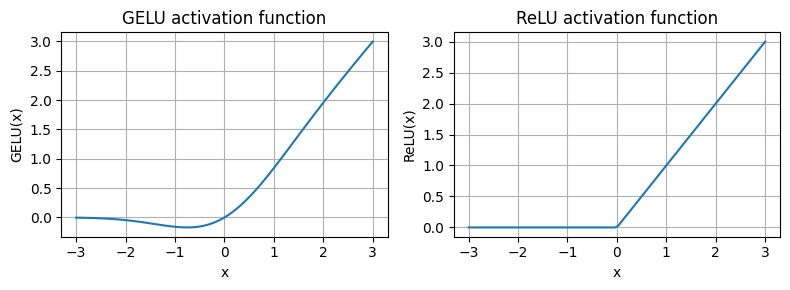

In [9]:
import matplotlib.pyplot as plt 
from barebone_llm.model import GELU
import torch.nn as nn

gelu, relu = GELU(),nn.ReLU()
x = torch.linspace(-3,3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8,3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
from barebone_llm.model import FeedForward
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


In [11]:
from barebone_llm.model import TransformerBlock 
torch.manual_seed(123)
x = torch.rand(2,4,768)
block = TransformerBlock(GPT_CONFIG_124M)
output= block(x)
print(f"Input shape = {x.shape}")
print(f"Output shape = {output.shape}")

Input shape = torch.Size([2, 4, 768])
Output shape = torch.Size([2, 4, 768])


In [12]:
from barebone_llm.model import GPTModel 
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print(f"Input batch = {batch}")
print(f"Output shape = {out.shape}")
print(out)

Input batch = tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape = torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [13]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range (max_new_tokens) : 
        idx_cond = idx[:, -context_size:]
        with torch.no_grad() : 
            logits = model(idx_cond) 
        logits = logits [:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim = True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [14]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print(f"encoded = {encoded}")
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print(f"encoded_tensor.shape = {encoded_tensor.shape}")

encoded = [15496, 11, 314, 716]
encoded_tensor.shape = torch.Size([1, 4])


In [15]:
model.eval()
out = generate_text_simple(
    model = model,
    idx = encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(f"Output = {out}")
print(f"Output length = {len(out[0])}")

Output = tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length = 10


In [16]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)


Hello, I am Featureiman Byeswickattribute argue
